In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [8]:
import json
import time
import requests
from pathlib import Path
from datetime import datetime, timezone

import pandas as pd
import numpy as np

# from bot_template import BaseBot, OrderBook, Order, OrderRequest, OrderResponse, Trade, Side, Product

In [39]:
THAMES_MEASURE = "0006-level-tidal_level-i-15_min-mAOD"

def get_thames(limit=400):
    """Fetch recent Thames tidal readings at Westminster.

    Returns DataFrame with: time, level (mAOD).
    Use limit=400 for ~4 days of history.
    """
    resp = requests.get(
        f"https://environment.data.gov.uk/flood-monitoring/id/measures/{THAMES_MEASURE}/readings",
        params={"_sorted": "", "_limit": limit},
    )
    resp.raise_for_status()
    items = resp.json().get("items", [])
    df = pd.DataFrame(items)[["dateTime", "value"]].rename(columns={"dateTime": "time", "value": "level"})
    df["time"] = pd.to_datetime(df["time"], utc=True).dt.tz_convert("Europe/London")
    return df.sort_values("time").reset_index(drop=True)

In [40]:

df_thames = get_thames(1450)

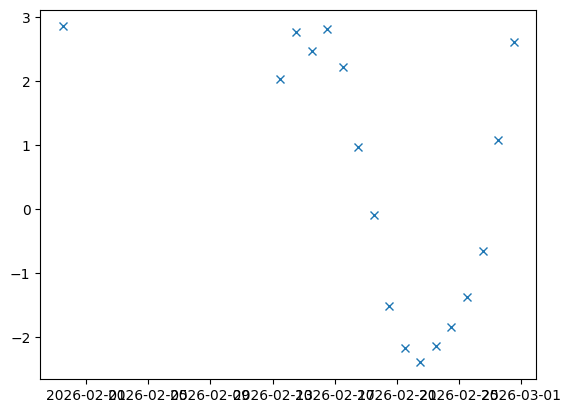

In [20]:
plt.plot(df_thames['time'], df_thames['level'], 'x')

In [24]:
df_thames = get_thames(1450)

2026-02-13 at 12pm: 2.025 mAOD
2026-02-14 at 12pm: 2.768 mAOD
2026-02-15 at 12pm: 2.465 mAOD
2026-02-16 at 12pm: 2.811 mAOD
2026-02-17 at 12pm: 2.210 mAOD
2026-02-18 at 12pm: 0.965 mAOD
2026-02-19 at 12pm: -0.098 mAOD
2026-02-20 at 12pm: -1.510 mAOD
2026-02-21 at 12pm: -2.166 mAOD
2026-02-22 at 12pm: -2.395 mAOD
2026-02-23 at 12pm: -2.139 mAOD
2026-02-24 at 12pm: -1.846 mAOD
2026-02-25 at 12pm: -1.379 mAOD
2026-02-26 at 12pm: -0.662 mAOD
2026-02-27 at 12pm: 1.080 mAOD
2026-02-28 at 12pm: 2.605 mAOD

Fitted sine curve parameters:
  Amplitude: 2.749 m
  Period: 359.05 hours (15.0 days)
  Phase: -41.82 hours (-1.7 days)
  Offset: 0.175 mAOD

🎯 PREDICTION for 2026-03-01 at 12pm: 2.705 mAOD
   TIDE_SPOT settlement value: 2705 mm


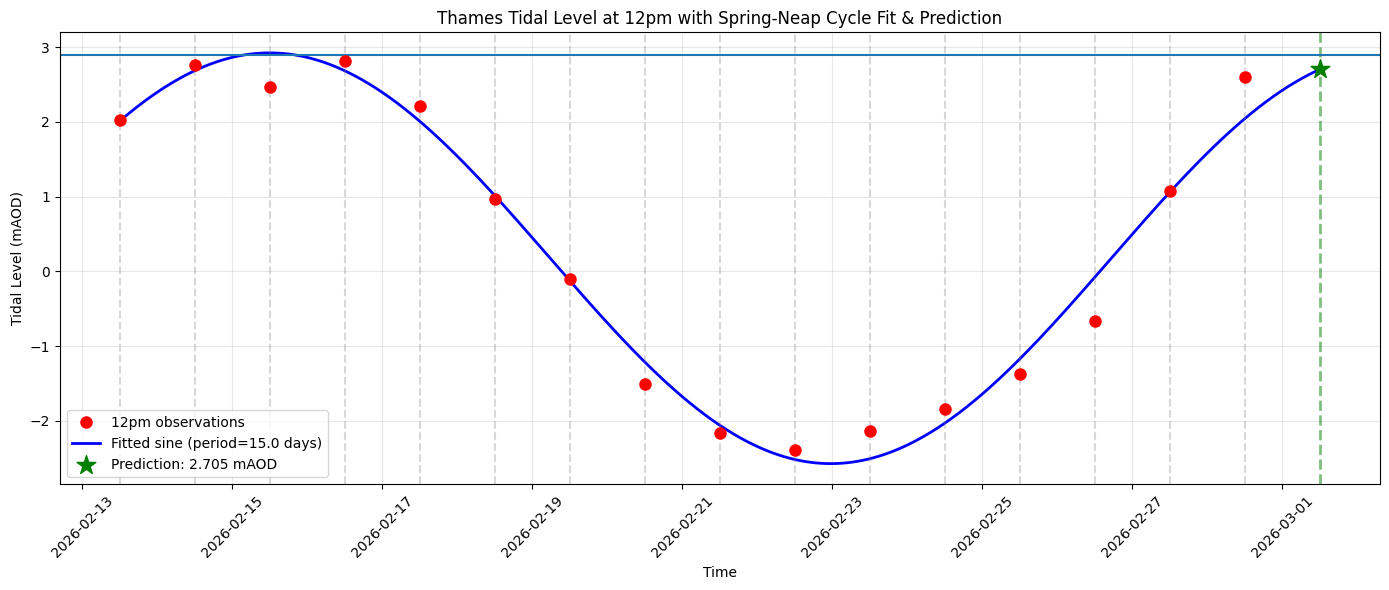

In [41]:
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
# Cubic spline interpolate and find values at 12pm
df_thames_interp = df_thames.set_index('time').sort_index()
df_thames_interp = df_thames_interp.resample('1min').interpolate(method='cubic')

# Find values at exactly 12pm for each day
noon_values = []
for date in df_thames['time'].dt.date.unique():
    noon = pd.Timestamp(f"{date} 12:00:00").tz_localize("Europe/London")
    if noon in df_thames_interp.index:
        value = df_thames_interp.loc[noon, 'level']
        noon_values.append({'date': date, 'time': noon, 'level': value})
        print(f"{date} at 12pm: {value:.3f} mAOD")

df_noon = pd.DataFrame(noon_values)

# Fit a sine curve to the 12pm values
def tidal_sine(x, amplitude, period, phase, offset):
    return amplitude * np.sin(2 * np.pi / period * (x - phase)) + offset

# Convert times to hours since first reading for fitting
if len(df_noon) > 0:
    x_data = (df_noon['time'] - df_noon['time'].iloc[0]).dt.total_seconds() / 3600
    y_data = df_noon['level'].values
    
    # Initial guess: amplitude ~1m, period ~15 days (360 hours)
    initial_guess = [1.0, 300, 0, 0]
    
    # Constrain period to be at least 15 days (360 hours)
    try:
        params, covariance = curve_fit(
            tidal_sine, x_data, y_data, 
            p0=initial_guess, 
            bounds=([0, 200, -np.inf, -np.inf], [np.inf, np.inf, np.inf, np.inf]),
            maxfev=10000
        )
        amplitude, period, phase, offset = params
        
        print(f"\nFitted sine curve parameters:")
        print(f"  Amplitude: {amplitude:.3f} m")
        print(f"  Period: {period:.2f} hours ({period/24:.1f} days)")
        print(f"  Phase: {phase:.2f} hours ({phase/24:.1f} days)")
        print(f"  Offset: {offset:.3f} mAOD")
        
        # Predict value at March 1, 2026 12pm (Sunday - settlement day)
        target_time = pd.Timestamp("2026-03-01 12:00:00").tz_localize("Europe/London")
        target_x = (target_time - df_noon['time'].iloc[0]).total_seconds() / 3600
        predicted_value = tidal_sine(target_x, *params)
        
        print(f"\n🎯 PREDICTION for 2026-03-01 at 12pm: {predicted_value:.3f} mAOD")
        print(f"   TIDE_SPOT settlement value: {abs(predicted_value * 1000):.0f} mm")
        
        # Generate fitted curve including extrapolation
        x_fit = np.linspace(x_data.min(), target_x, 1000)
        y_fit = tidal_sine(x_fit, *params)
        time_fit = df_noon['time'].iloc[0] + pd.to_timedelta(x_fit, unit='h')
        
        # Plot
        plt.figure(figsize=(14, 6))
        plt.plot(df_noon['time'], df_noon['level'], 'ro', markersize=8, label='12pm observations', zorder=3)
        plt.plot(time_fit, y_fit, 'b-', linewidth=2, label=f'Fitted sine (period={period/24:.1f} days)', zorder=2)
        plt.scatter([target_time], [predicted_value], color='green', s=200, marker='*', 
                   label=f'Prediction: {predicted_value:.3f} mAOD', zorder=4)
        
        # Add vertical lines at 12pm
        for _, row in df_noon.iterrows():
            plt.axvline(x=row['time'], color='gray', linestyle='--', alpha=0.3)
        plt.axvline(x=target_time, color='green', linestyle='--', alpha=0.5, linewidth=2)
        
        plt.xlabel('Time')
        plt.ylabel('Tidal Level (mAOD)')
        plt.title('Thames Tidal Level at 12pm with Spring-Neap Cycle Fit & Prediction')
        plt.legend()
        plt.grid(True, alpha=0.3)
        plt.xticks(rotation=45)
        plt.axhline(2.9)
        plt.tight_layout()
        plt.show()
        
    except Exception as e:
        print(f"Curve fitting failed: {e}")

In [45]:
zz  = get_thames(1450)

In [47]:
zz['diff'] = zz['level'].diff()

In [48]:
zz

,time,level,diff
0,2026-02-13 11:45:00+00:00,2.262,NaN
1,2026-02-13 12:00:00+00:00,2.025,-0.237
2,2026-02-13 12:15:00+00:00,1.786,-0.239
3,2026-02-13 12:30:00+00:00,1.544,-0.242
4,2026-02-13 12:45:00+00:00,1.299,-0.245
...,...,...,...
1445,2026-02-28 13:00:00+00:00,1.510,-0.299
1446,2026-02-28 13:15:00+00:00,1.241,-0.269
1447,2026-02-28 13:30:00+00:00,0.954,-0.287
1448,2026-02-28 13:45:00+00:00,0.698,-0.256


In [42]:
# Calculate 15-minute changes in tidal level and compute TIDE_SWING strangle payoff
df_thames = get_thames(1450)
df_thames_sorted = df_thames.sort_values('time').reset_index(drop=True)

# Calculate 15-minute differences
df_thames_sorted['diff_m'] = df_thames_sorted['level'].diff()
df_thames_sorted['diff_cm'] = abs(df_thames_sorted['diff_m'] * 100)

# Strangle payoff: strikes at 20 and 25 cm
df_thames_sorted['put_payoff'] = np.maximum(0, 20 - df_thames_sorted['diff_cm'])
df_thames_sorted['call_payoff'] = np.maximum(0, df_thames_sorted['diff_cm'] - 25)
df_thames_sorted['strangle_payoff'] = df_thames_sorted['put_payoff'] + df_thames_sorted['call_payoff']

# Sum all payoffs for TIDE_SWING settlement
tide_swing_total = df_thames_sorted['strangle_payoff'].sum()

print(f"TIDE_SWING Settlement (sum of strangle payoffs): {tide_swing_total:.1f}")
print(f"\nBreakdown:")
print(f"  Total put payoffs: {df_thames_sorted['put_payoff'].sum():.1f}")
print(f"  Total call payoffs: {df_thames_sorted['call_payoff'].sum():.1f}")
print(f"  15-min intervals with payoff > 0: {(df_thames_sorted['strangle_payoff'] > 0).sum()}")

# Show some example intervals
print(f"\nSample intervals:")
sample = df_thames_sorted[df_thames_sorted['strangle_payoff'] > 0].head(10)
for _, row in sample.iterrows():
    print(f"  {row['time']}: diff={row['diff_cm']:.1f}cm -> put={row['put_payoff']:.1f} + call={row['call_payoff']:.1f} = {row['strangle_payoff']:.1f}")

TIDE_SWING Settlement (sum of strangle payoffs): 8439.9

Breakdown:
  Total put payoffs: 4794.5
  Total call payoffs: 3645.4
  15-min intervals with payoff > 0: 1147

Sample intervals:
  2026-02-13 13:30:00+00:00: diff=18.9cm -> put=1.1 + call=0.0 = 1.1
  2026-02-13 14:00:00+00:00: diff=19.8cm -> put=0.2 + call=0.0 = 0.2
  2026-02-13 14:15:00+00:00: diff=18.8cm -> put=1.2 + call=0.0 = 1.2
  2026-02-13 14:30:00+00:00: diff=16.4cm -> put=3.6 + call=0.0 = 3.6
  2026-02-13 14:45:00+00:00: diff=19.7cm -> put=0.3 + call=0.0 = 0.3
  2026-02-13 15:00:00+00:00: diff=16.0cm -> put=4.0 + call=0.0 = 4.0
  2026-02-13 15:15:00+00:00: diff=13.5cm -> put=6.5 + call=0.0 = 6.5
  2026-02-13 15:30:00+00:00: diff=14.5cm -> put=5.5 + call=0.0 = 5.5
  2026-02-13 15:45:00+00:00: diff=12.3cm -> put=7.7 + call=0.0 = 7.7
  2026-02-13 16:00:00+00:00: diff=8.8cm -> put=11.2 + call=0.0 = 11.2


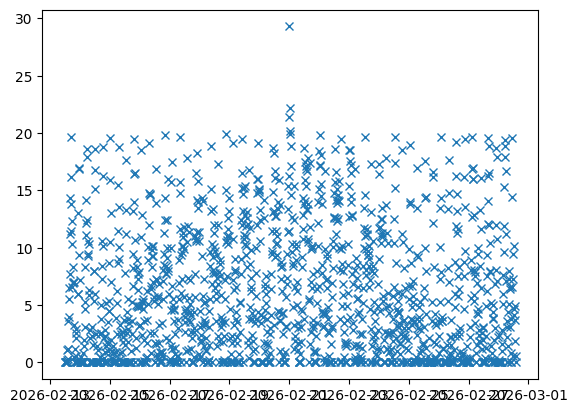

In [43]:
plt.plot(df_thames_sorted['time'], df_thames_sorted['strangle_payoff'],'x')

In [27]:
df = df_thames.sort_values("time").reset_index(drop=True).copy()

# 15-min absolute difference in metres
df["diff_m"] = df["level"].diff().abs().fillna(0.0)

K_put = 0.20
K_call = 0.25

df["put_payoff"]  = np.maximum(0.0, K_put - df["diff_m"])
df["call_payoff"] = np.maximum(0.0, df["diff_m"] - K_call)
df["strangle_value"] = df["put_payoff"] + df["call_payoff"]

tide_swing_settlement = 100.0 * df["strangle_value"].sum()

print(f"TIDE_SWING settlement: {tide_swing_settlement:.2f}")

TIDE_SWING settlement: 864.20
